# Lab 4: Regression Analysis with Regularization Techniques (Diabetes Dataset)

**Name:** Suresh Ghimire  
**Course:** MSCS 634 – Advanced Big Data and Data Mining  
**Professor** Satish Penmatsa  
**Lab 4:** Regression Analysis with Regularization Techniques 


### Step 1: Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes

# Optional display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# Load dataset
diabetes = load_diabetes()

# Features and target
X = diabetes.data
y = diabetes.target

# Convert to DataFrame for easier exploration
df = pd.DataFrame(X, columns=diabetes.feature_names)
df["target"] = y

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature names:", diabetes.feature_names)

df.head()

Feature matrix shape: (442, 10)
Target shape: (442,)

Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [3]:
# Missing values check
missing_values = df.isnull().sum()
print("Missing values per column:\n")
print(missing_values)

Missing values per column:

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


The dataset was checked for missing values and none were found, so no imputation or removal was required.

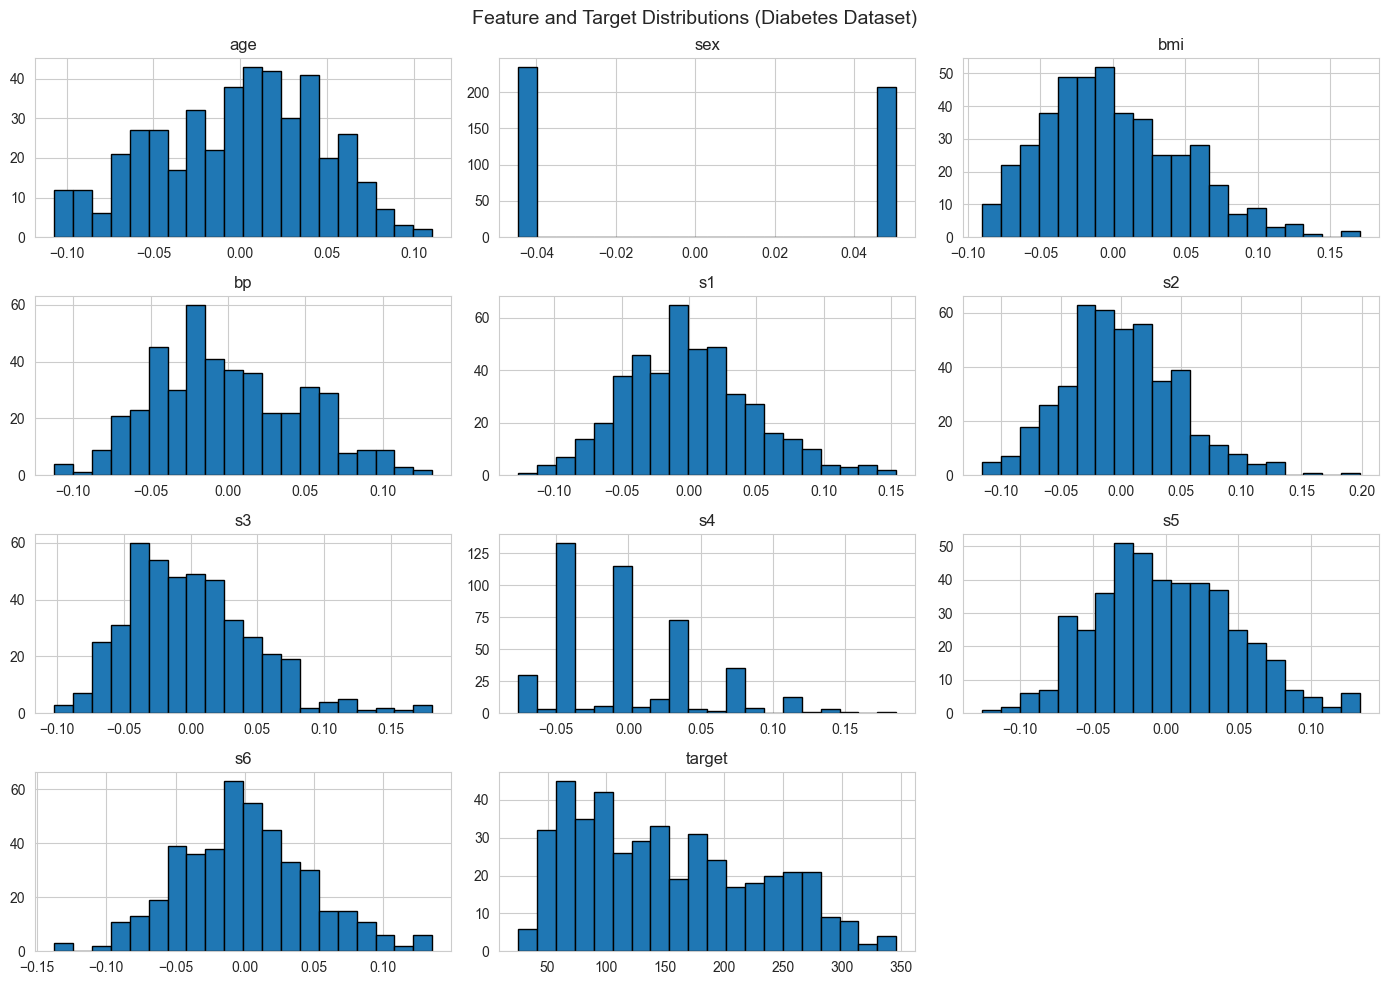

In [4]:
# Histograms for all features + target
df.hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Feature and Target Distributions (Diabetes Dataset)", fontsize=14)
plt.tight_layout()
plt.show()

### Step 2: Linear Regression

***2.1 Select One Feature (bmi)***

In [5]:
# Simple Linear Regression using one feature: bmi
feature_name = "bmi"

X_simple = df[[feature_name]]   # 2D input for sklearn
y = df["target"]                # target variable

print("X_simple shape:", X_simple.shape)
print("y shape:", y.shape)
X_simple.head()

X_simple shape: (442, 1)
y shape: (442,)


,bmi
0,0.061696
1,-0.051474
2,0.044451
3,-0.011595
4,-0.036385


***2.2 Train/Test Split***

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

Training set size: 353
Testing set size: 89


***2.3 Train Simple Linear Regression Model***

In [7]:
from sklearn.linear_model import LinearRegression

simple_lr = LinearRegression()
simple_lr.fit(X_train, y_train)

print("Intercept:", simple_lr.intercept_)
print("Coefficient:", simple_lr.coef_[0])

Intercept: 152.00335421448167
Coefficient: 998.5776891375593


***2.4 Make Predictions***

In [8]:
y_pred_simple = simple_lr.predict(X_test)

# Preview actual vs predicted
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_simple
})

comparison_df.head(10)

,Actual,Predicted
0,219.0,145.806227
1,70.0,188.857390
2,202.0,147.958785
3,230.0,203.925298
4,111.0,131.814599
5,84.0,127.509482
6,242.0,322.315998
7,272.0,197.467623
8,94.0,61.856458
9,96.0,167.331809


***2.5 Evaluate the Model (MAE, MSE, RMSE, R²)***

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_simple = mean_absolute_error(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression Performance (feature = bmi)")
print(f"MAE  : {mae_simple:.4f}")
print(f"MSE  : {mse_simple:.4f}")
print(f"RMSE : {rmse_simple:.4f}")
print(f"R²   : {r2_simple:.4f}")

Simple Linear Regression Performance (feature = bmi)
MAE  : 52.2600
MSE  : 4061.8259
RMSE : 63.7325
R²   : 0.2334


***2.6 Visualize Predictions vs Actual Data (Scatter + Regression Line)***

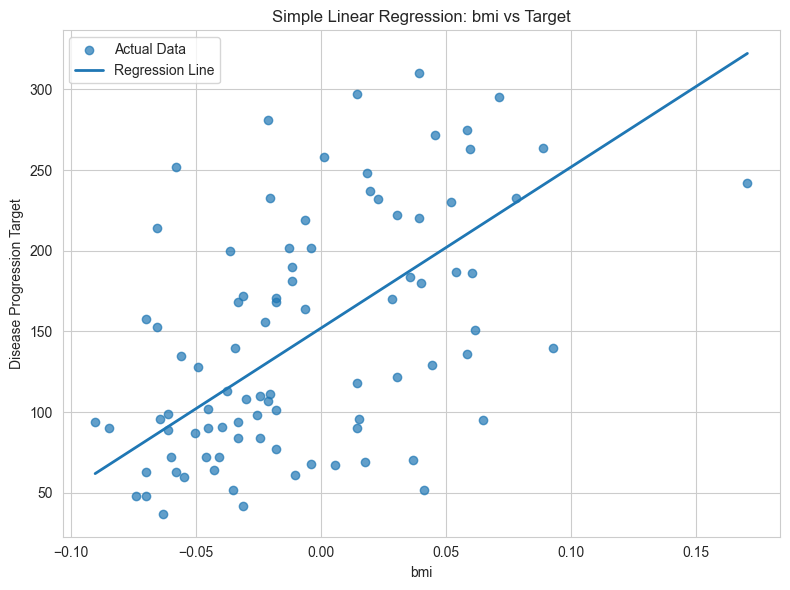

In [10]:
# Sort test values for a clean regression line plot
sorted_idx = np.argsort(X_test[feature_name].values)
X_test_sorted = X_test.iloc[sorted_idx]
y_pred_sorted = y_pred_simple[sorted_idx]

plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, alpha=0.7, label="Actual Data")
plt.plot(X_test_sorted, y_pred_sorted, linewidth=2, label="Regression Line")

plt.xlabel(feature_name)
plt.ylabel("Disease Progression Target")
plt.title(f"Simple Linear Regression: {feature_name} vs Target")
plt.legend()

plt.tight_layout()
plt.savefig("images/step2_simple_lr_bmi_vs_target.png", dpi=300, bbox_inches="tight")

plt.show()

The plot shows a positive relationship between BMI and the diabetes progression target. As BMI increases, the regression line indicates that the predicted target value also tends to increase.
However, the data points are spread out around the line, which means BMI alone does not fully explain the target variation. This suggests the simple linear model captures the overall trend but has limited accuracy, and using multiple features may improve performance.

***2.7 Visualize Actual vs Predicted***

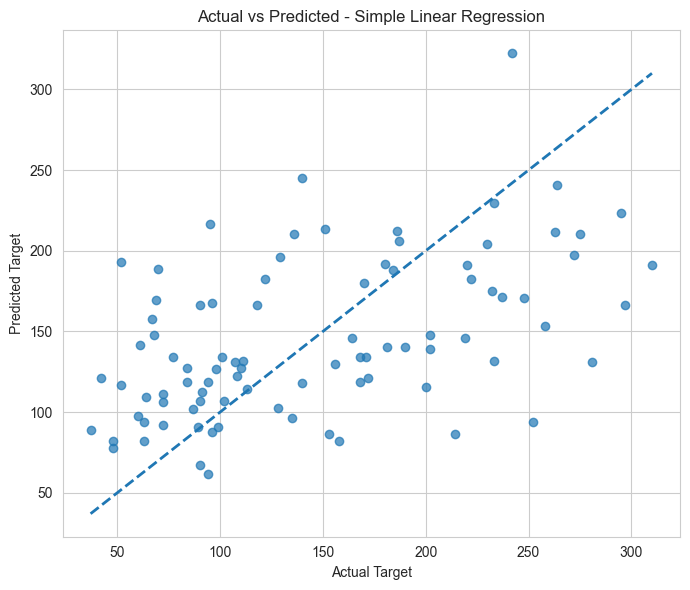

In [11]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_simple, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=2
)
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predicted - Simple Linear Regression")

plt.tight_layout()
plt.savefig("images/step2_actual_vs_pred_simple.png", dpi=300, bbox_inches="tight")
plt.show()


The Actual vs Predicted plot shows that the model captures the overall trend, but many points are not close to the diagonal reference line. This indicates prediction errors are still present and the simple linear regression model has limited accuracy when using only BMI as the predictor.

In [12]:
results = []

results.append({
    "Model": "Simple Linear Regression (bmi)",
    "MAE": mae_simple,
    "MSE": mse_simple,
    "RMSE": rmse_simple,
    "R2": r2_simple
})

pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression (bmi),52.259976,4061.825928,63.732456,0.23335


### Step 3: Multiple Linear Regression

***3.1 Prepare Feature***

In [13]:
# Use all feature columns (exclude target)
X_multi = df.drop(columns=["target"])
y = df["target"]

print("X_multi shape:", X_multi.shape)
print("y shape:", y.shape)
X_multi.head()

X_multi shape: (442, 10)
y shape: (442,)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


***3.2 Train or Test Split***

In [14]:
from sklearn.model_selection import train_test_split

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train_m.shape[0])
print("Testing set size:", X_test_m.shape[0])

Training set size: 353
Testing set size: 89


***3.4 Train Multiple Linear Regression Model***

In [15]:
from sklearn.linear_model import LinearRegression

multi_lr = LinearRegression()
multi_lr.fit(X_train_m, y_train_m)

print("Intercept:", multi_lr.intercept_)

coef_df = pd.DataFrame({
    "Feature": X_multi.columns,
    "Coefficient": multi_lr.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

coef_df

Intercept: 151.34560453985995


,Feature,Coefficient
4,s1,-931.488846
8,s5,736.198859
2,bmi,542.428759
5,s2,518.062277
3,bp,347.703844
7,s4,275.317902
1,sex,-241.964362
6,s3,163.419983
9,s6,48.670657
0,age,37.904021


***3.5 Make Prediction***

In [16]:
y_pred_multi = multi_lr.predict(X_test_m)

comparison_multi = pd.DataFrame({
    "Actual": y_test_m.values,
    "Predicted": y_pred_multi
})

comparison_multi.head(10)

,Actual,Predicted
0,219.0,139.547558
1,70.0,179.517208
2,202.0,134.038756
3,230.0,291.417029
4,111.0,123.789659
5,84.0,92.172347
6,242.0,258.232389
7,272.0,181.337321
8,94.0,90.224113
9,96.0,108.633759


***3.6 Evaluate Model (MAE, MSE, RMSE, R²)***

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_multi = mean_absolute_error(y_test_m, y_pred_multi)
mse_multi = mean_squared_error(y_test_m, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test_m, y_pred_multi)

print("Multiple Linear Regression Performance (all features)")
print(f"MAE  : {mae_multi:.4f}")
print(f"MSE  : {mse_multi:.4f}")
print(f"RMSE : {rmse_multi:.4f}")
print(f"R²   : {r2_multi:.4f}")

Multiple Linear Regression Performance (all features)
MAE  : 42.7941
MSE  : 2900.1936
RMSE : 53.8534
R²   : 0.4526


***3.7 Actual vs Predicted Plot (Multiple Regression)***

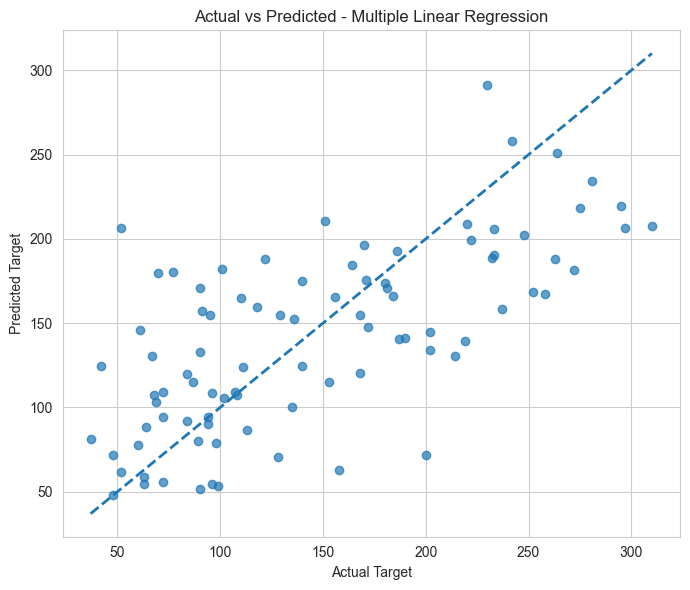

In [18]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_m, y_pred_multi, alpha=0.7)
plt.plot(
    [y_test_m.min(), y_test_m.max()],
    [y_test_m.min(), y_test_m.max()],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predicted - Multiple Linear Regression")

plt.tight_layout()
plt.savefig("images/step3_actual_vs_pred_multiple.png", dpi=300, bbox_inches="tight")

plt.show()

The Actual vs Predicted plot for multiple linear regression shows a better alignment with the diagonal reference line compared to the simple linear regression model. This indicates that using all features improves the model’s predictive performance.

Although the model captures the overall trend more effectively, some points still deviate from the diagonal line, showing that prediction errors remain. Overall, the multiple regression model provides a stronger fit than the single-feature model.

***3.8 Residual Plot***

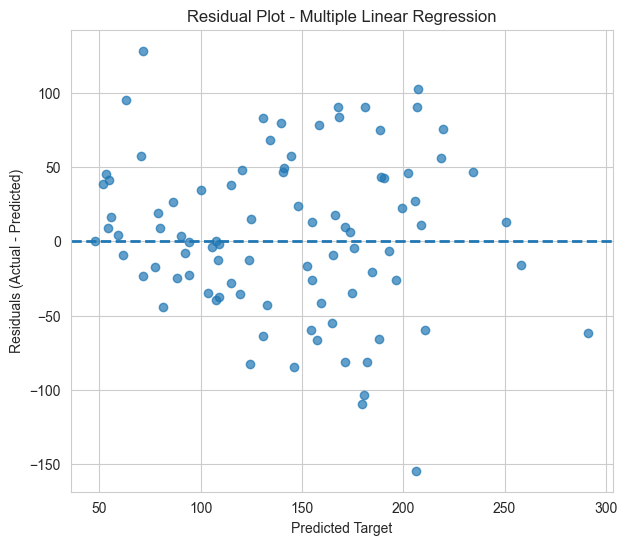

In [19]:
residuals_multi = y_test_m - y_pred_multi

plt.figure(figsize=(7, 6))
plt.scatter(y_pred_multi, residuals_multi, alpha=0.7)
plt.axhline(y=0, linestyle="--", linewidth=2)

plt.xlabel("Predicted Target")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot - Multiple Linear Regression")
plt.show()

***3.9 Final Comparision***

In [20]:
results.append({
    "Model": "Multiple Linear Regression (all features)",
    "MAE": mae_multi,
    "MSE": mse_multi,
    "RMSE": rmse_multi,
    "R2": r2_multi
})

pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression (bmi),52.259976,4061.825928,63.732456,0.233350
1,Multiple Linear Regression (all features),42.794095,2900.193628,53.853446,0.452603


### Step 4: Polynomial Regression

***4.1 Import Polynomial Features***

In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

***4.2 Train Polynomial Regression***

In [22]:
# Reuse the same simple feature split from Step 2


poly_deg2_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("lr", LinearRegression())
])

poly_deg2_model.fit(X_train, y_train)
y_pred_poly2 = poly_deg2_model.predict(X_test)

***4.3 Evaluate Polynomial Regression - Degree=2***

In [23]:
mae_poly2 = mean_absolute_error(y_test, y_pred_poly2)
mse_poly2 = mean_squared_error(y_test, y_pred_poly2)
rmse_poly2 = np.sqrt(mse_poly2)
r2_poly2 = r2_score(y_test, y_pred_poly2)

print("Polynomial Regression Performance (degree = 2, feature = bmi)")
print(f"MAE  : {mae_poly2:.4f}")
print(f"MSE  : {mse_poly2:.4f}")
print(f"RMSE : {rmse_poly2:.4f}")
print(f"R²   : {r2_poly2:.4f}")

Polynomial Regression Performance (degree = 2, feature = bmi)
MAE  : 52.3839
MSE  : 4085.0255
RMSE : 63.9142
R²   : 0.2290


***4.4 Visualize Polynomial Curve - Degree=2***

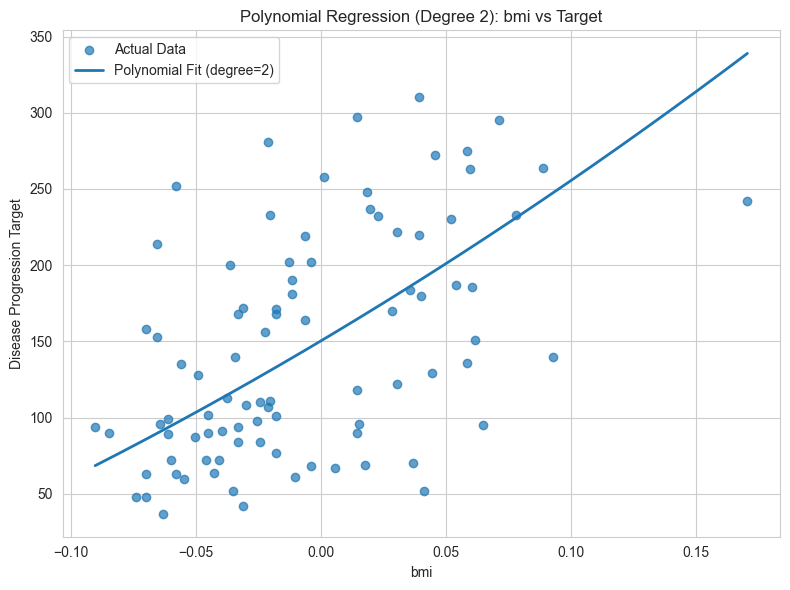

In [24]:
# Create smooth x-values for plotting the polynomial curve
x_min, x_max = X_simple[feature_name].min(), X_simple[feature_name].max()
x_curve = pd.DataFrame(
    np.linspace(x_min, x_max, 200),
    columns=[feature_name]
)

y_curve_poly2 = poly_deg2_model.predict(x_curve)

plt.figure(figsize=(8, 6))
plt.scatter(X_test, y_test, alpha=0.7, label="Actual Data")
plt.plot(x_curve, y_curve_poly2, linewidth=2, label="Polynomial Fit (degree=2)")

plt.xlabel(feature_name)
plt.ylabel("Disease Progression Target")
plt.title("Polynomial Regression (Degree 2): bmi vs Target")
plt.legend()

plt.tight_layout()
plt.savefig("images/step4_polynomial_curve_degree_2.png", dpi=300, bbox_inches="tight")

plt.show()

The degree-2 polynomial regression curve shows a slightly more flexible fit than the simple linear regression line, allowing the model to capture some non-linear pattern between BMI and the target. However, the data points remain widely scattered, indicating that using BMI alone still limits predictive accuracy.

***4.5 Train and Compare Degrees (1, 2, 3, 4, 5)***

In [25]:
poly_results = []

degrees = [1, 2, 3, 4, 5]

for d in degrees:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("lr", LinearRegression())
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    poly_results.append({
        "Degree": d,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

poly_results_df = pd.DataFrame(poly_results)
poly_results_df

,Degree,MAE,MSE,RMSE,R2
0,1,52.259976,4061.825928,63.732456,0.233350
1,2,52.383912,4085.025481,63.914204,0.228972
2,3,52.181400,4064.443384,63.752987,0.232856
3,4,52.376339,4226.144878,65.008806,0.202336
4,5,51.884611,4085.845567,63.920619,0.228817


***4.6 Plot Polynomial Fits for Different Degrees***

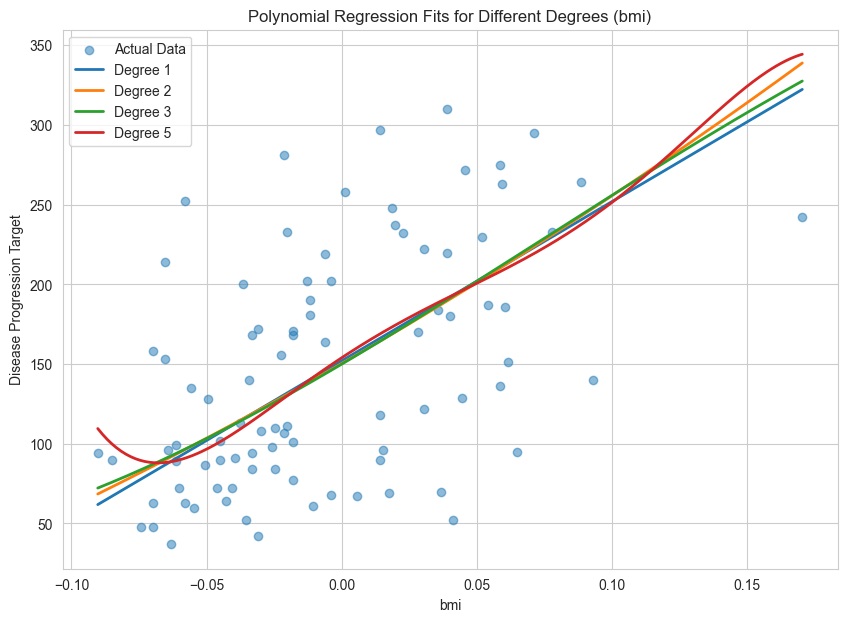

In [26]:
plt.figure(figsize=(10, 7))
plt.scatter(X_test, y_test, alpha=0.5, label="Actual Data")

x_curve = pd.DataFrame(
    np.linspace(x_min, x_max, 300),
    columns=[feature_name]
)

for d in [1, 2, 3, 5]:
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("lr", LinearRegression())
    ])
    model.fit(X_train, y_train)
    y_curve = model.predict(x_curve)
    plt.plot(x_curve, y_curve, linewidth=2, label=f"Degree {d}")

plt.xlabel(feature_name)
plt.ylabel("Disease Progression Target")
plt.title("Polynomial Regression Fits for Different Degrees (bmi)")
plt.legend()
plt.show()

The polynomial fit plot shows that higher-degree models produce more flexible curves than degree 1 (linear regression). Degree 2 and degree 3 slightly adjust the trend, while degree 5 bends more strongly, indicating increased model complexity. This demonstrates how increasing polynomial degree can improve fit to non-linear patterns, but also raises the risk of overfitting.

***4. 8 Actual vs Predicted***

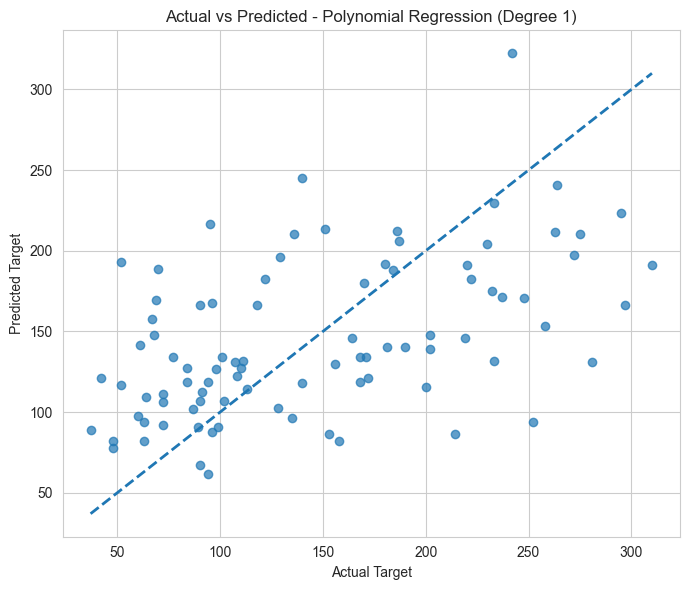

In [27]:
# Example: choose best degree based on highest R2
best_degree = poly_results_df.sort_values("R2", ascending=False).iloc[0]["Degree"]
best_degree = int(best_degree)

best_poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("lr", LinearRegression())
])

best_poly_model.fit(X_train, y_train)
y_pred_best_poly = best_poly_model.predict(X_test)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best_poly, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title(f"Actual vs Predicted - Polynomial Regression (Degree {best_degree})")

plt.tight_layout()
plt.savefig("images/step4_polynomial_fits_different_degrees.png", dpi=300, bbox_inches="tight")

plt.show()

In [28]:
best_row = poly_results_df.sort_values("R2", ascending=False).iloc[0]

results.append({
    "Model": f"Polynomial Regression (bmi, degree={int(best_row['Degree'])})",
    "MAE": best_row["MAE"],
    "MSE": best_row["MSE"],
    "RMSE": best_row["RMSE"],
    "R2": best_row["R2"]
})

pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression (bmi),52.259976,4061.825928,63.732456,0.233350
1,Multiple Linear Regression (all features),42.794095,2900.193628,53.853446,0.452603
2,"Polynomial Regression (bmi, degree=1)",52.259976,4061.825928,63.732456,0.233350


### Step 5: Regularization with Ridge and Lasso Regression

***5.1 Imports for Ridge/Lasso***

In [29]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

***5.2 Train Ridge and Lasso***

In [30]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=1.0, max_iter=10000))
])

ridge_model.fit(X_train_m, y_train_m)
lasso_model.fit(X_train_m, y_train_m)

y_pred_ridge = ridge_model.predict(X_test_m)
y_pred_lasso = lasso_model.predict(X_test_m)

***5.3 Evaluate Ridge and Lasso***

In [31]:
# Ridge metrics
mae_ridge = mean_absolute_error(y_test_m, y_pred_ridge)
mse_ridge = mean_squared_error(y_test_m, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test_m, y_pred_ridge)

# Lasso metrics
mae_lasso = mean_absolute_error(y_test_m, y_pred_lasso)
mse_lasso = mean_squared_error(y_test_m, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test_m, y_pred_lasso)

print("Ridge Regression (alpha=1.0)")
print(f"MAE  : {mae_ridge:.4f}")
print(f"MSE  : {mse_ridge:.4f}")
print(f"RMSE : {rmse_ridge:.4f}")
print(f"R²   : {r2_ridge:.4f}")

print("\nLasso Regression (alpha=1.0)")
print(f"MAE  : {mae_lasso:.4f}")
print(f"MSE  : {mse_lasso:.4f}")
print(f"RMSE : {rmse_lasso:.4f}")
print(f"R²   : {r2_lasso:.4f}")

Ridge Regression (alpha=1.0)
MAE  : 42.8120
MSE  : 2892.0146
RMSE : 53.7775
R²   : 0.4541

Lasso Regression (alpha=1.0)
MAE  : 42.8030
MSE  : 2824.5681
RMSE : 53.1467
R²   : 0.4669


Ridge and Lasso both perform similarly, but Lasso (alpha = 1.0) shows slightly better results with lower MSE/RMSE and higher R² than Ridge. This suggests Lasso is giving a slightly better fit on the test set for this dataset.

***5.4 Actual vs Predicted (Ridge)***

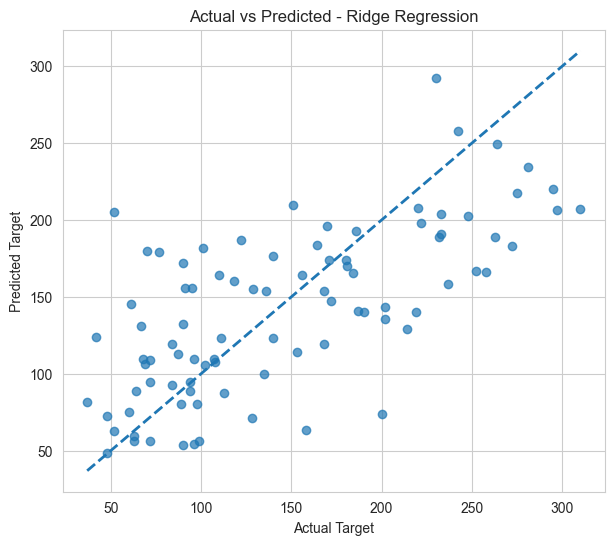

In [32]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_m, y_pred_ridge, alpha=0.7)
plt.plot(
    [y_test_m.min(), y_test_m.max()],
    [y_test_m.min(), y_test_m.max()],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predicted - Ridge Regression")
plt.show()

The Ridge plot shows a clear positive trend, and many points follow the diagonal line. However, some points still deviate noticeably, indicating prediction errors remain even though Ridge performs better than simple regression

***5.5 Actual vs Predicted (Lasso)***

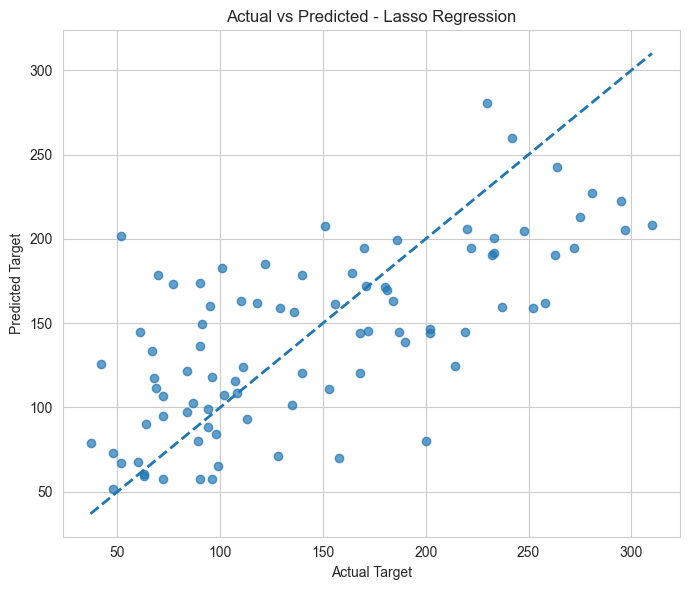

In [33]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_m, y_pred_lasso, alpha=0.7)
plt.plot(
    [y_test_m.min(), y_test_m.max()],
    [y_test_m.min(), y_test_m.max()],
    linestyle="--",
    linewidth=2
)

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predicted - Lasso Regression")

plt.tight_layout()
plt.savefig("images/step5_ridge_actual_vs_pred.png", dpi=300, bbox_inches="tight")
plt.show()

The Lasso plot also shows a strong alignment with the diagonal reference line. Compared to Ridge, the spread looks slightly more consistent, which matches the slightly better evaluation metrics for Lasso.

***5.6 Compare Coefficients (Ridge vs Lasso)***

In [34]:
ridge_coefs = ridge_model.named_steps["ridge"].coef_
lasso_coefs = lasso_model.named_steps["lasso"].coef_

coef_compare = pd.DataFrame({
    "Feature": X_multi.columns,
    "Ridge_Coefficient": ridge_coefs,
    "Lasso_Coefficient": lasso_coefs
})

coef_compare["Lasso_Zeroed"] = coef_compare["Lasso_Coefficient"].apply(lambda x: abs(x) < 1e-8)
coef_compare.sort_values(by="Ridge_Coefficient", key=abs, ascending=False)

,Feature,Ridge_Coefficient,Lasso_Coefficient,Lasso_Zeroed
4,s1,-34.671954,-8.228172,False
8,s5,31.378384,22.636465,False
2,bmi,25.732699,26.219225,False
5,s2,17.053075,-0.000000,True
3,bp,16.734300,15.657314,False
7,s4,11.764260,3.420861,False
1,sex,-11.448190,-9.297519,False
6,s3,3.369914,-9.024087,False
9,s6,2.458139,2.098647,False
0,age,1.807342,0.687032,False


Ridge shrinks all coefficients but keeps them nonzero, while Lasso applies stronger shrinkage. In this result, Lasso sets s2 to zero, showing feature selection behavior, which is a key difference between Ridge and Lasso.

***5.7 Test Different Alpha Values (Ridge and Lasso)***

In [35]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_alpha_results = []
lasso_alpha_results = []

for a in alphas:
    # Ridge
    ridge = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=a))
    ])
    ridge.fit(X_train_m, y_train_m)
    y_pred_r = ridge.predict(X_test_m)

    ridge_alpha_results.append({
        "Alpha": a,
        "MAE": mean_absolute_error(y_test_m, y_pred_r),
        "MSE": mean_squared_error(y_test_m, y_pred_r),
        "RMSE": np.sqrt(mean_squared_error(y_test_m, y_pred_r)),
        "R2": r2_score(y_test_m, y_pred_r)
    })

    # Lasso
    lasso = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=a, max_iter=10000))
    ])
    lasso.fit(X_train_m, y_train_m)
    y_pred_l = lasso.predict(X_test_m)

    lasso_alpha_results.append({
        "Alpha": a,
        "MAE": mean_absolute_error(y_test_m, y_pred_l),
        "MSE": mean_squared_error(y_test_m, y_pred_l),
        "RMSE": np.sqrt(mean_squared_error(y_test_m, y_pred_l)),
        "R2": r2_score(y_test_m, y_pred_l)
    })

ridge_alpha_df = pd.DataFrame(ridge_alpha_results)
lasso_alpha_df = pd.DataFrame(lasso_alpha_results)

print("Ridge alpha comparison")
display(ridge_alpha_df)

print("\nLasso alpha comparison")
display(lasso_alpha_df)

Ridge alpha comparison


,Alpha,MAE,MSE,RMSE,R2
0,0.01,42.794171,2900.075130,53.852346,0.452625
1,0.10,42.796235,2899.054556,53.842869,0.452818
2,1.00,42.811999,2892.014566,53.777454,0.454147
3,10.00,42.856825,2875.778718,53.626288,0.457211
4,100.00,43.250653,2858.224287,53.462363,0.460524



Lasso alpha comparison


,Alpha,MAE,MSE,RMSE,R2
0,0.01,42.795018,2898.368019,53.836493,0.452947
1,0.10,42.805234,2884.624289,53.708698,0.455541
2,1.00,42.802984,2824.568094,53.146666,0.466877
3,10.00,44.764599,2933.834730,54.164885,0.446253
4,100.00,64.006461,5361.533457,73.222493,-0.011963


***5.8 Visualize Alpha vs R² (Ridge vs Lasso)***

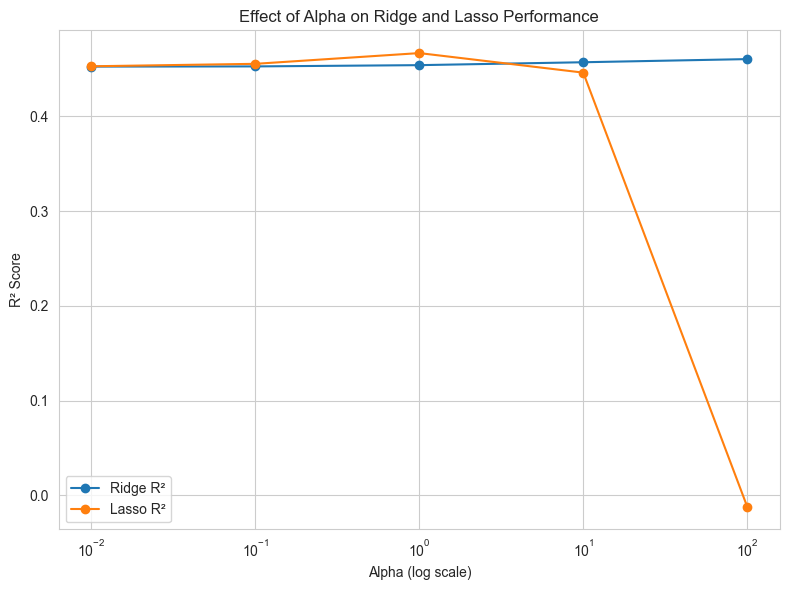

In [36]:
plt.figure(figsize=(8, 6))
plt.plot(ridge_alpha_df["Alpha"], ridge_alpha_df["R2"], marker="o", label="Ridge R²")
plt.plot(lasso_alpha_df["Alpha"], lasso_alpha_df["R2"], marker="o", label="Lasso R²")

plt.xscale("log")
plt.xlabel("Alpha (log scale)")
plt.ylabel("R² Score")
plt.title("Effect of Alpha on Ridge and Lasso Performance")
plt.legend()

plt.tight_layout()
plt.savefig("images/step5_lasso_actual_vs_pred.png", dpi=300, bbox_inches="tight")
plt.show()

Ridge performance stays relatively stable across different alpha values, while Lasso improves around smaller-to-moderate alpha values and then drops sharply at very high alpha (100). This shows that too much regularization can reduce model performance, especially for Lasso.

***5.9 Add Best Ridge/Lasso Results to Final results Table***

In [37]:
best_ridge = ridge_alpha_df.sort_values("R2", ascending=False).iloc[0]
best_lasso = lasso_alpha_df.sort_values("R2", ascending=False).iloc[0]

results.append({
    "Model": f"Ridge Regression (alpha={best_ridge['Alpha']})",
    "MAE": best_ridge["MAE"],
    "MSE": best_ridge["MSE"],
    "RMSE": best_ridge["RMSE"],
    "R2": best_ridge["R2"]
})

results.append({
    "Model": f"Lasso Regression (alpha={best_lasso['Alpha']})",
    "MAE": best_lasso["MAE"],
    "MSE": best_lasso["MSE"],
    "RMSE": best_lasso["RMSE"],
    "R2": best_lasso["R2"]
})

pd.DataFrame(results)

,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression (bmi),52.259976,4061.825928,63.732456,0.233350
1,Multiple Linear Regression (all features),42.794095,2900.193628,53.853446,0.452603
2,"Polynomial Regression (bmi, degree=1)",52.259976,4061.825928,63.732456,0.233350
3,Ridge Regression (alpha=100.0),43.250653,2858.224287,53.462363,0.460524
4,Lasso Regression (alpha=1.0),42.802984,2824.568094,53.146666,0.466877


The final comparison table shows that Lasso Regression (alpha = 1.0) achieved the best overall performance among the listed models with the highest R² and lowest RMSE. Multiple Linear Regression also performed well, while simple and polynomial regression (using only BMI) had lower accuracy.

### Step 6: Model Comparison and Analysis

***Step 6.1 Final Result***

In [38]:
final_results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False).reset_index(drop=True)
final_results_df

,Model,MAE,MSE,RMSE,R2
0,Lasso Regression (alpha=1.0),42.802984,2824.568094,53.146666,0.466877
1,Ridge Regression (alpha=100.0),43.250653,2858.224287,53.462363,0.460524
2,Multiple Linear Regression (all features),42.794095,2900.193628,53.853446,0.452603
3,Simple Linear Regression (bmi),52.259976,4061.825928,63.732456,0.233350
4,"Polynomial Regression (bmi, degree=1)",52.259976,4061.825928,63.732456,0.233350


***Step 6.2 Visualize Model Comparison (R²)***

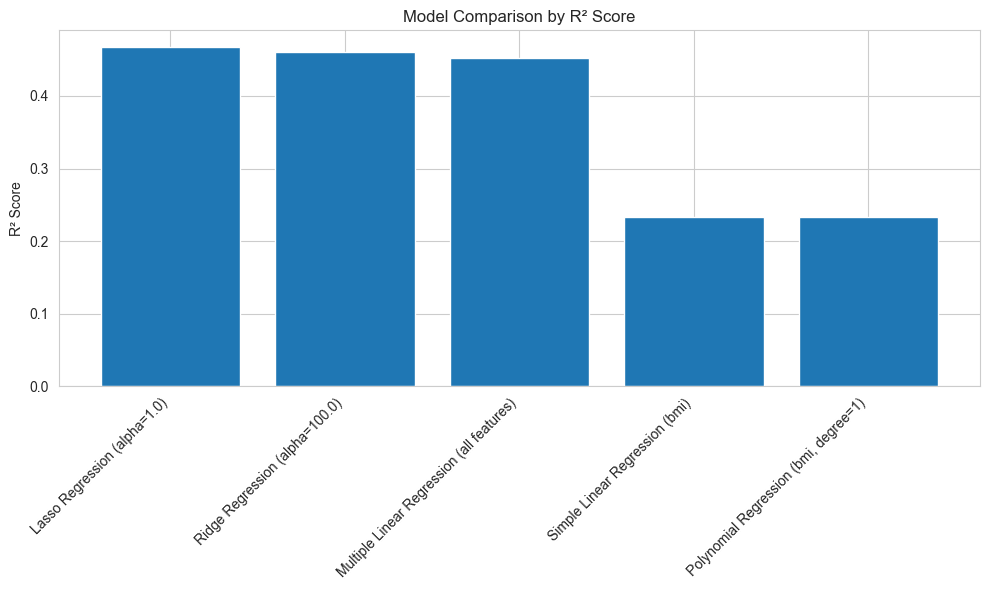

In [39]:
plt.figure(figsize=(10, 6))
plt.bar(final_results_df["Model"], final_results_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R² Score")
plt.title("Model Comparison by R² Score")
plt.tight_layout()

plt.savefig("images/step6_model_comparison_r2.png", dpi=300, bbox_inches="tight")
plt.show()

***Steo=p 6.3 Visualize Model Comparison (RMSE)***

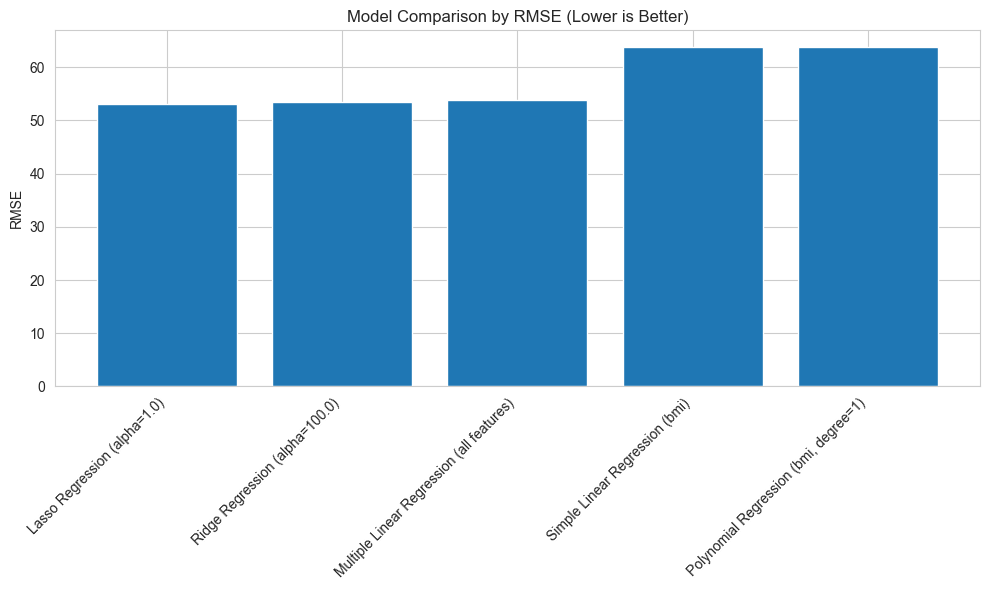

In [40]:
plt.figure(figsize=(10, 6))
plt.bar(final_results_df["Model"], final_results_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE (Lower is Better)")
plt.tight_layout()

plt.tight_layout()
plt.savefig("images/step6_model_comparison_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

The final model comparison shows clear performance differences across the regression techniques. Lasso Regression (alpha = 1.0) achieved the best overall performance with the highest R² and lowest RMSE, followed closely by Ridge Regression and Multiple Linear Regression. This indicates that adding regularization improved generalization compared to standard linear regression.

The Simple Linear Regression and Polynomial Regression (using only BMI) produced lower R² scores and higher error values, showing that a single feature was not sufficient to capture the complexity of the diabetes progression target. While polynomial regression increased model flexibility, it did not outperform models that used all available features.

A key observation is that regularization helped control model complexity, especially in Lasso, which also performed feature selection by shrinking at least one coefficient to zero. The alpha comparison further showed that very large alpha values can overshrink coefficients and reduce performance, particularly for Lasso.

Overall, the lab demonstrates that the Diabetes dataset benefits from multi-feature models, and that Ridge/Lasso regularization can improve prediction performance while reducing overfitting risk.